# Imports

In [18]:
import os 
from PIL import Image
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

tf.keras.utils.set_random_seed(42)


## Inläsning av data

In [19]:
train_dir = "train"
test_dir = "test"

IMG_SIZE = (48, 48)
BATCH_SIZE = 64

train_data = keras.utils.image_dataset_from_directory(
    train_dir,
    color_mode="grayscale",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    validation_split=0.2,
    subset="training",
    seed=42
)

val_data = keras.utils.image_dataset_from_directory(
    train_dir,
    color_mode="grayscale",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    validation_split=0.2,
    subset="validation",
    seed=42
)

test_data = keras.utils.image_dataset_from_directory(
    test_dir,
    color_mode="grayscale",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

class_names = train_data.class_names
print("Class names:", class_names)

normalization_layer = layers.Rescaling(1./255)

Found 28709 files belonging to 7 classes.
Using 22968 files for training.
Found 28709 files belonging to 7 classes.
Using 5741 files for validation.
Found 7178 files belonging to 7 classes.
Class names: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


In [21]:
# Limit dataser for faster training
train_dataset = train_data.take(80)
val_dataset = val_data.take(20)
test_dataset = test_data

Training pictures per class:
angry: 3995 pictures
disgust: 436 pictures
fear: 4097 pictures
happy: 7215 pictures
neutral: 4965 pictures
sad: 4830 pictures
surprise: 3171 pictures


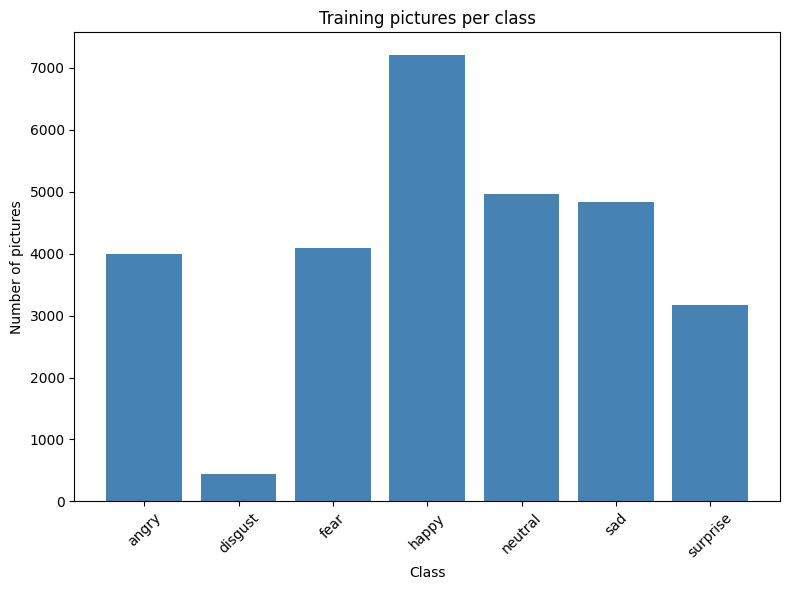

In [22]:
# Räknar bilder i träningsdatan

print("Training pictures per class:")
count = {}
for c in class_names:
    antal = len(os.listdir(os.path.join(train_dir, c)))
    count[c] = antal
    print(f"{c}: {antal} pictures")

# Fördelning av klass

plt.figure(figsize=(8, 6))
plt.bar(count.keys(), count.values(), color='steelblue')
plt.title('Training pictures per class')
plt.ylabel('Number of pictures')
plt.xlabel('Class')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

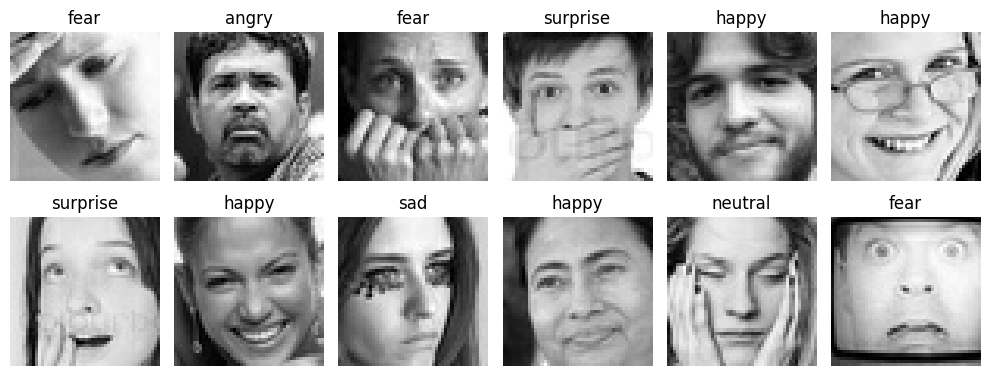

In [23]:
plt.figure(figsize=(10, 4))

for images, labels in train_data.take(1):
    for i in range(12):
        plt.subplot(2, 6, i + 1)
        plt.imshow(images[i].numpy().squeeze(), cmap='gray')
        plt.title(class_names[labels[i]])
        plt.axis('off')
        
    plt.tight_layout()
    plt.show()